# LIMOncello — Notebook kiểm tra Jacobian và debug filter

Notebook này tập trung vào **cách kiểm tra đúng/sai của Jacobian** trong `State.hpp`, đặc biệt là các phần:

- `df_dx(...)`: Jacobian của mô hình động học theo state.
- `df_dw()`: Jacobian của mô hình động học theo noise.
- `h_model(...)`: Jacobian của residual point-to-plane trong LiDAR update.
- Vòng lặp IESEKF: dấu của residual, hội tụ, covariance, rank/observability.

Ý tưởng chính: mỗi công thức trong code đều nên có một bài test sai phân hữu hạn:

\[
J_{\mathrm{FD}}[:,i]
= \frac{f(x \oplus \epsilon e_i)-f(x \oplus (-\epsilon e_i))}{2\epsilon}.
\]

Với biến rotation/Lie group, tuyệt đối không cộng thẳng vào ma trận quay. Ta perturb bằng:

\[
R(\delta\theta)=R\operatorname{Exp}(\delta\theta).
\]

Trong code C++ của LIMOncello, prediction dùng Eq. (7)–(8) và Eq. (15)–(16) của paper; update dùng residual point-to-plane Eq. (17)–(18) và MAP update Eq. (20). `State.hpp` hiện thực hóa các phần đó qua `predict()`, `df_dx()`, `df_dw()`, `update()`.


## 0. Bản đồ index của state

Trong `State.hpp`, state danh nghĩa là bundle:

\[
x=(\Gamma,{}^I T_L,b_\omega,b_a,g)
\in SGal(3)\times SE(3)\times \mathbb R^3\times\mathbb R^3\times S^2.
\]

State được lưu theo kích thước ambient là 25, nhưng covariance của error-state chỉ có 24 chiều vì gravity trên \(S^2\) chỉ có 2 bậc tự do.

| Khối | Index trong tangent ambient | Số chiều | Ghi chú |
|---|---:|---:|---|
| position \(\rho\) | 0..2 | 3 | trong `SGal3` |
| velocity \(\nu\) | 3..5 | 3 | trong `SGal3` |
| rotation \(\theta\) | 6..8 | 3 | trong `SGal3` |
| time \(\iota\) | 9 | 1 | trong `SGal3` |
| extrinsics \({}^I T_L\) | 10..15 | 6 | `SE3` |
| gyro bias \(b_\omega\) | 16..18 | 3 | `R3` |
| accel bias \(b_a\) | 19..21 | 3 | `R3` |
| gravity ambient | 22..24 | 3 | lưu 3D, nhưng error-state chỉ 2D |

Các test bên dưới cố tình dùng đúng thứ tự index này.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

DoF = 25
DoFS2 = 24
DoFNoise = 12
DoFObs = 16

state_blocks = [
    ("SGal3 position rho", "0..2", 3),
    ("SGal3 velocity nu", "3..5", 3),
    ("SGal3 rotation theta", "6..8", 3),
    ("SGal3 time iota", "9", 1),
    ("SE3 extrinsics", "10..15", 6),
    ("gyro bias b_w", "16..18", 3),
    ("accel bias b_a", "19..21", 3),
    ("gravity ambient", "22..24", 3),
]

try:
    import pandas as pd
    display(pd.DataFrame(state_blocks, columns=["Block", "Index", "Dim"]))
except Exception:
    for row in state_blocks:
        print(row)


,Block,Index,Dim
0,SGal3 position rho,0..2,3
1,SGal3 velocity nu,3..5,3
2,SGal3 rotation theta,6..8,3
3,SGal3 time iota,9,1
4,SE3 extrinsics,10..15,6
5,gyro bias b_w,16..18,3
6,accel bias b_a,19..21,3
7,gravity ambient,22..24,3


## 1. Utility toán học dùng cho kiểm tra sai phân hữu hạn

Ta cần 3 hàm cơ bản:

\[
[x]_\times =
\begin{bmatrix}
0&-x_z&x_y\\
x_z&0&-x_x\\
-x_y&x_x&0
\end{bmatrix},
\]

\[
\operatorname{Exp}(\phi)=I+rac{\sin\theta}{\theta}[\phi]_\times+rac{1-\cos\theta}{\theta^2}[\phi]^2_\times,
\quad \theta=\|\phi\|.
\]

Quy ước perturb rotation trong notebook này là **right perturbation**:

\[
R'(\delta\theta)=R\operatorname{Exp}(\delta\theta).
\]

Quy ước này khớp với kiểu `X.plus(tau)` mà code dùng trong prediction/update.


In [2]:
def skew(x):
    """Ma trận skew-symmetric [x]_x sao cho skew(x) @ y = x cross y."""
    x = np.asarray(x, dtype=float).reshape(3)
    return np.array([
        [0.0, -x[2], x[1]],
        [x[2], 0.0, -x[0]],
        [-x[1], x[0], 0.0],
    ])


def exp_so3(phi):
    """SO(3) exponential map từ axis-angle vector sang rotation matrix."""
    phi = np.asarray(phi, dtype=float).reshape(3)
    theta = np.linalg.norm(phi)
    K = skew(phi)
    if theta < 1e-12:
        return np.eye(3) + K + 0.5 * K @ K
    A = np.sin(theta) / theta
    B = (1.0 - np.cos(theta)) / (theta * theta)
    return np.eye(3) + A * K + B * K @ K


def random_rotation(seed=0, angle=0.7):
    rng = np.random.default_rng(seed)
    axis = rng.normal(size=3)
    axis /= np.linalg.norm(axis)
    return exp_so3(axis * angle)


def central_difference(func, x0, eps=1e-6):
    """Jacobian sai phân trung tâm của func: R^n -> R^m."""
    x0 = np.asarray(x0, dtype=float)
    y0 = np.asarray(func(x0), dtype=float).reshape(-1)
    J = np.zeros((y0.size, x0.size))
    for k in range(x0.size):
        dx = np.zeros_like(x0)
        dx[k] = eps
        fp = np.asarray(func(x0 + dx), dtype=float).reshape(-1)
        fm = np.asarray(func(x0 - dx), dtype=float).reshape(-1)
        J[:, k] = (fp - fm) / (2.0 * eps)
    return J


def report_error(name, J_analytic, J_fd, tol=1e-7):
    err = np.max(np.abs(J_analytic - J_fd))
    status = "PASS" if err < tol else "CHECK"
    print(f"{name:38s} max|J-J_fd| = {err:.3e}  [{status}]")
    return err


## 2. Kiểm tra `df_dx(...)`

Trong code:

```cpp
out.block<3, 3>(3,  6) = -manif::skew(R().transpose()*g());
out.block<3, 3>(3, 19) = -I;
out.block<3, 3>(3, 22) = -R().transpose();
out.block<3, 3>(6, 16) = -I;
```

Mô hình increment chính trong `f()` là:

\[
\nu = a_m-b_a-R^\top g,
\qquad
\theta = \omega_m-b_\omega.
\]

Vì perturb rotation theo bên phải:

\[
(R\operatorname{Exp}(\delta\theta))^\top g
= \operatorname{Exp}(\delta\theta)^\top R^\top g
\approx R^\top g + [R^\top g]_\times\delta\theta.
\]

Do đó:

\[
\frac{\partial(a_m-b_a-R^\top g)}{\partial \delta\theta}
= -[R^\top g]_\times.
\]

Đây là chỗ rất dễ sai dấu.


df_dx block wrt rotation theta         max|J-J_fd| = 4.473e-10  [PASS]
df_dx block wrt accel bias b_a         max|J-J_fd| = 3.043e-10  [PASS]
df_dx block wrt gravity g              max|J-J_fd| = 8.942e-10  [PASS]
df_dx block wrt gyro bias b_w          max|J-J_fd| = 5.939e-12  [PASS]


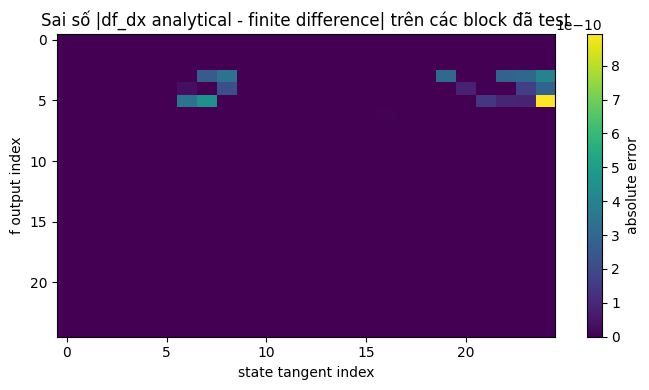

In [3]:
# State giả lập để test df_dx
R = random_rotation(seed=1, angle=0.8)
g = np.array([0.2, -0.3, 9.81])
lin_acc = np.array([0.4, -0.2, 9.6])
ang_vel = np.array([0.1, 0.2, -0.1])
b_a = np.array([0.05, -0.03, 0.02])
b_w = np.array([0.01, -0.02, 0.03])


def f_ambient(R_, b_a_, b_w_, g_):
    """Bản Python của State::f(), trả về tangent ambient 25 chiều."""
    out = np.zeros(DoF)
    out[3:6] = lin_acc - b_a_ - R_.T @ g_
    out[6:9] = ang_vel - b_w_
    out[9] = 1.0
    return out

# Jacobian analytical giống State::df_dx()
J_dx = np.zeros((DoF, DoF))
J_dx[3:6, 6:9] = -skew(R.T @ g)
J_dx[3:6, 19:22] = -np.eye(3)
J_dx[3:6, 22:25] = -R.T
J_dx[6:9, 16:19] = -np.eye(3)

# Sai phân wrt rotation right perturbation
J_rot_fd = central_difference(
    lambda dtheta: f_ambient(R @ exp_so3(dtheta), b_a, b_w, g),
    np.zeros(3),
)

# Sai phân wrt accel bias
J_ba_fd = central_difference(
    lambda dba: f_ambient(R, b_a + dba, b_w, g),
    np.zeros(3),
)

# Sai phân wrt gravity ambient 3D
J_g_fd = central_difference(
    lambda dg: f_ambient(R, b_a, b_w, g + dg),
    np.zeros(3),
)

# Sai phân wrt gyro bias
J_bw_fd = central_difference(
    lambda dbw: f_ambient(R, b_a, b_w + dbw, g),
    np.zeros(3),
)

err1 = report_error("df_dx block wrt rotation theta", J_dx[:, 6:9], J_rot_fd)
err2 = report_error("df_dx block wrt accel bias b_a", J_dx[:, 19:22], J_ba_fd)
err3 = report_error("df_dx block wrt gravity g", J_dx[:, 22:25], J_g_fd)
err4 = report_error("df_dx block wrt gyro bias b_w", J_dx[:, 16:19], J_bw_fd)

# Heatmap lỗi cho toàn bộ các block được test ghép lại
J_fd_blocks = np.zeros_like(J_dx)
J_fd_blocks[:, 6:9] = J_rot_fd
J_fd_blocks[:, 19:22] = J_ba_fd
J_fd_blocks[:, 22:25] = J_g_fd
J_fd_blocks[:, 16:19] = J_bw_fd

plt.figure(figsize=(7, 4))
plt.imshow(np.abs(J_dx - J_fd_blocks), aspect="auto")
plt.colorbar(label="absolute error")
plt.title("Sai số |df_dx analytical - finite difference| trên các block đã test")
plt.xlabel("state tangent index")
plt.ylabel("f output index")
plt.tight_layout()
plt.show()


### Chọn epsilon thế nào?

Sai phân hữu hạn có hai lỗi đối nghịch:

- \(\epsilon\) quá lớn: lỗi do phi tuyến.
- \(\epsilon\) quá nhỏ: lỗi do floating point cancellation.

Với `double`, khoảng \(10^{-6}\) đến \(10^{-7}\) thường là vùng ổn cho Jacobian cỡ này.


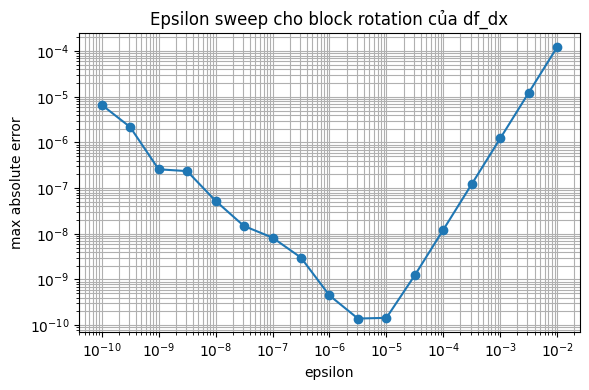

epsilon tốt nhất trong sweep này ≈ 3.2e-06


In [4]:
eps_values = np.logspace(-10, -2, 17)
errors = []
for eps in eps_values:
    J_rot_fd_eps = central_difference(
        lambda dtheta: f_ambient(R @ exp_so3(dtheta), b_a, b_w, g),
        np.zeros(3),
        eps=eps,
    )
    errors.append(np.max(np.abs(J_dx[:, 6:9] - J_rot_fd_eps)))

plt.figure(figsize=(6, 4))
plt.loglog(eps_values, errors, marker="o")
plt.title("Epsilon sweep cho block rotation của df_dx")
plt.xlabel("epsilon")
plt.ylabel("max absolute error")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

best = eps_values[int(np.argmin(errors))]
print(f"epsilon tốt nhất trong sweep này ≈ {best:.1e}")


## 3. Kiểm tra `df_dw()`

Trong code, noise vector được sắp theo:

\[
w = [n_\omega, n_a, n_{b_\omega}, n_{b_a}].
\]

Mô hình có dạng:

\[
\theta = \omega_m-b_\omega-n_\omega,
\]

\[
\nu = a_m-b_a-n_a-R^\top g,
\]

\[
\dot b_\omega = n_{b_\omega},
\qquad
\dot b_a = n_{b_a}.
\]

Vì vậy các block trong code là:

```cpp
out.block<3, 3>( 6, 0) = -I; // wrt n_w
out.block<3, 3>( 3, 3) = -I; // wrt n_a
out.block<3, 3>(16, 6) =  I; // wrt n_{b_w}
out.block<3, 3>(19, 9) =  I; // wrt n_{b_a}
```


df_dw all blocks                       max|J-J_fd| = 7.484e-10  [PASS]


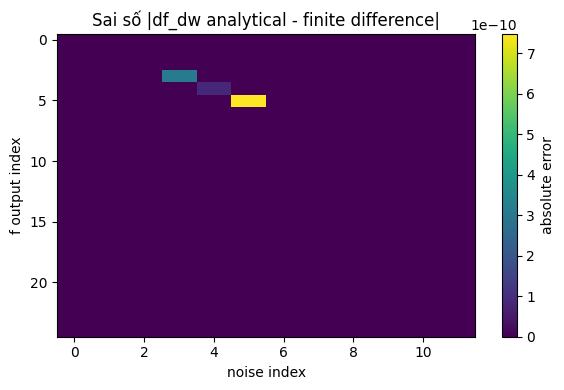

In [5]:
def f_with_noise(noise):
    """State::f() nếu ta bật các noise comment trong code."""
    noise = np.asarray(noise).reshape(DoFNoise)
    n_w = noise[0:3]
    n_a = noise[3:6]
    n_bw = noise[6:9]
    n_ba = noise[9:12]

    out = np.zeros(DoF)
    out[3:6] = lin_acc - b_a - n_a - R.T @ g
    out[6:9] = ang_vel - b_w - n_w
    out[9] = 1.0
    out[16:19] = n_bw
    out[19:22] = n_ba
    return out

J_dw = np.zeros((DoF, DoFNoise))
J_dw[6:9, 0:3] = -np.eye(3)
J_dw[3:6, 3:6] = -np.eye(3)
J_dw[16:19, 6:9] = np.eye(3)
J_dw[19:22, 9:12] = np.eye(3)

J_dw_fd = central_difference(f_with_noise, np.zeros(DoFNoise))
err_dw = report_error("df_dw all blocks", J_dw, J_dw_fd)

plt.figure(figsize=(6, 4))
plt.imshow(np.abs(J_dw - J_dw_fd), aspect="auto")
plt.colorbar(label="absolute error")
plt.title("Sai số |df_dw analytical - finite difference|")
plt.xlabel("noise index")
plt.ylabel("f output index")
plt.tight_layout()
plt.show()


## 4. Kiểm tra Jacobian residual point-to-plane trong `update()`

Trong `h_model`, code tạo:

\[
g = \pi(\Gamma)\,{}^I T_L\,p^L,
\]

rồi residual hình học là:

\[
r = n^\top g + d.
\]

Nhưng code đặt:

```cpp
H = derivative of r
z = -dist2plane(...)
```

Do đó phương trình tuyến tính mà filter giải là:

\[
H\delta x \approx z = -r.
\]

Nếu bạn so `H` với đạo hàm của `z`, bạn sẽ thấy lệch dấu. Đúng là phải so `H` với đạo hàm của \(r\), không phải của \(z\).

### 4.1 Jacobian wrt `SGal3`

Với \(p^I = {}^I T_L p^L\), action của `manif::SGal3::act(p, J_s)` có Jacobian theo tangent order \((\rho,\nu,\theta,\iota)\):

\[
J_s =
\begin{bmatrix}
R & 0 & -R[p^I]_\times & v
\end{bmatrix}.
\]

Vì thế:

\[
H_\Gamma = n^\top J_s.
\]

Điểm tinh tế: bản thân hàm `act(p)` trả \(t+Rp\), nhưng khi perturb `SGal3` theo tangent **time** ở bên phải, thành phần translation đổi thêm \(v\,\delta\iota\). Vì vậy cột time của Jacobian là \(v\), đúng như implementation của `manif`.

### 4.2 Jacobian wrt extrinsics `SE3`

Với perturb bên phải:

\[
{}^I T_L(\delta)={}^I T_L\operatorname{Exp}(\rho_e,\theta_e),
\]

ta có:

\[
\frac{\partial g}{\partial \delta_e}
=
\begin{bmatrix}
R_{WI}R_{IL} & -R_{WI}R_{IL}[p^L]_\times
\end{bmatrix}.
\]

Vì vậy:

\[
H_e=n^\top
\begin{bmatrix}
R_{WI}R_{IL} & -R_{WI}R_{IL}[p^L]_\times
\end{bmatrix}.
\]


In [6]:
# Một residual point-to-plane giả lập
R_WI = random_rotation(seed=2, angle=0.6)
t_WI = np.array([1.0, 2.0, 3.0])
v_WI = np.array([0.5, -0.1, 0.2])

R_IL = random_rotation(seed=4, angle=0.35)
t_IL = np.array([0.1, 0.2, -0.05])
p_L = np.array([2.0, 0.5, 1.0])

n = np.array([0.2, -0.3, 0.93])
n = n / np.linalg.norm(n)

p_I = R_IL @ p_L + t_IL
g_W = t_WI + R_WI @ p_I
# Chọn mặt phẳng không đi đúng qua g_W để residual khác 0
q_on_plane = g_W + np.array([0.1, -0.2, 0.05])
d = -n @ q_on_plane


def residual_sgal(delta10):
    """Residual r khi perturb SGal3 bên phải: (rho, nu, theta, iota)."""
    delta10 = np.asarray(delta10).reshape(10)
    rho = delta10[0:3]
    theta = delta10[6:9]
    iota = delta10[9]
    # Composition SGal3 bên phải: translation đổi bởi R*rho + v*iota, rotation đổi bởi R*Exp(theta)
    g_delta = t_WI + R_WI @ rho + v_WI * iota + R_WI @ exp_so3(theta) @ p_I
    return np.array([n @ g_delta + d])


def residual_ext(delta6):
    """Residual r khi perturb extrinsics SE3 bên phải: (rho_e, theta_e)."""
    delta6 = np.asarray(delta6).reshape(6)
    rho_e = delta6[0:3]
    theta_e = delta6[3:6]
    p_I_delta = t_IL + R_IL @ rho_e + R_IL @ exp_so3(theta_e) @ p_L
    g_delta = t_WI + R_WI @ p_I_delta
    return np.array([n @ g_delta + d])

# Analytical H
J_s = np.c_[R_WI, np.zeros((3, 3)), -R_WI @ skew(p_I), v_WI.reshape(3, 1)]
H_s = n @ J_s

J_e = np.c_[R_WI @ R_IL, -R_WI @ R_IL @ skew(p_L)]
H_e = n @ J_e

H_s_fd = central_difference(residual_sgal, np.zeros(10)).reshape(10)
H_e_fd = central_difference(residual_ext, np.zeros(6)).reshape(6)

report_error("point-to-plane H wrt SGal3", H_s.reshape(1, -1), H_s_fd.reshape(1, -1))
report_error("point-to-plane H wrt extrinsics", H_e.reshape(1, -1), H_e_fd.reshape(1, -1))

print("\nH_s analytical:", H_s)
print("H_s finite diff:", H_s_fd)
print("\nH_e analytical:", H_e)
print("H_e finite diff:", H_e_fd)

r0 = residual_sgal(np.zeros(10))[0]
z0 = -r0
print(f"\nr0 = {r0:+.6f}, z0 = -r0 = {z0:+.6f}")
print("Nhớ: H là đạo hàm của r, còn z là -r.")


point-to-plane H wrt SGal3             max|J-J_fd| = 5.922e-10  [PASS]
point-to-plane H wrt extrinsics        max|J-J_fd| = 6.316e-10  [PASS]

H_s analytical: [ 0.65108  -0.000824  0.759008  0.        0.        0.        1.085205
 -0.765891 -0.931725  0.316809]
H_s finite diff: [ 0.65108  -0.000824  0.759008  0.        0.        0.        1.085205
 -0.765891 -0.931725  0.316809]

H_e analytical: [ 0.626393 -0.3049    0.717404  0.663602 -0.808415 -0.922996]
H_e finite diff: [ 0.626393 -0.3049    0.717404  0.663602 -0.808415 -0.922996]

r0 = -0.126824, z0 = -r0 = +0.126824
Nhớ: H là đạo hàm của r, còn z là -r.


## 5. Debug dấu của update bằng ví dụ một mặt phẳng

Đây là test cực kỳ hữu ích khi filter bị “nổ” sau update.

Giả sử mặt phẳng map là:

\[
z=0,
\qquad n=[0,0,1]^\top,
\qquad d=0.
\]

Ta tạo một scan gồm các điểm thật nằm trên mặt phẳng đó, nhưng state dự đoán bị sai roll, pitch và height. Nếu dùng đúng convention:

\[
H\delta x \approx -r,
\]

residual RMS phải giảm rất nhanh. Nếu lỡ dùng \(z=r\), residual sẽ tăng.


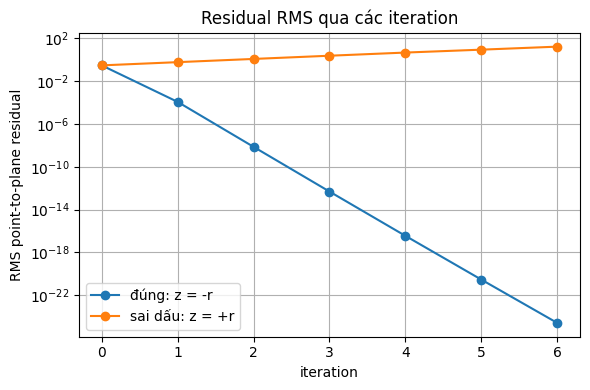

Residual RMS đúng dấu: [0.28792  0.000113 0.       0.       0.       0.       0.      ]
Residual RMS sai dấu: [ 0.28792   0.575696  1.150394  2.293025  4.521666  8.436525 16.120971]

Correction dx ở iteration đầu [rho_x rho_y rho_z theta_x theta_y theta_z]:
[-0.007888 -0.009684 -0.249663 -0.038788  0.031591  0.      ]

Singular values của H ở iteration đầu:
[41.04431  39.078636 14.118686  0.        0.        0.      ]
Rank hiệu dụng của H: 3 / 6
Gợi ý đọc: một mặt phẳng ngang chỉ quan sát mạnh z, roll, pitch; x, y, yaw gần như không quan sát được.


In [7]:
def make_plane_points(num=200, seed=10):
    rng = np.random.default_rng(seed)
    xy = rng.uniform(-5.0, 5.0, size=(num, 2))
    z = np.zeros((num, 1))
    return np.c_[xy, z]


def residuals_and_H_pose(R, t, points, n=np.array([0.0, 0.0, 1.0]), d=0.0):
    """SE3 pose-only version: g = t + R p, H = dr/d(rho,theta)."""
    N = points.shape[0]
    r = np.zeros(N)
    H = np.zeros((N, 6))
    for i, p in enumerate(points):
        g = t + R @ p
        r[i] = n @ g + d
        H[i, 0:3] = n @ R
        H[i, 3:6] = n @ (-R @ skew(p))
    return r, H


def run_plane_update(sign=-1.0, max_iters=6):
    """
    sign=-1: đúng, z=-r.
    sign=+1: sai dấu, z=+r.
    """
    points = make_plane_points()
    R_est = exp_so3(np.array([0.04, -0.03, 0.08]))
    t_est = np.array([0.2, -0.1, 0.25])

    P = np.diag([0.5, 0.5, 0.5, 0.1, 0.1, 0.1])
    meas_var = 0.01

    hist = []
    dx_hist = []
    sv_hist = []

    for _ in range(max_iters):
        r, H = residuals_and_H_pose(R_est, t_est, points)
        hist.append(np.sqrt(np.mean(r**2)))
        sv_hist.append(np.linalg.svd(H, compute_uv=False))

        z = sign * r
        A = H.T @ H / meas_var + np.linalg.inv(P)
        b = H.T @ z / meas_var
        dx = np.linalg.solve(A, b)
        dx_hist.append(dx)

        # Right perturbation pose update: T <- T Exp(dx)
        rho = dx[0:3]
        theta = dx[3:6]
        t_est = t_est + R_est @ rho
        R_est = R_est @ exp_so3(theta)

    r, _ = residuals_and_H_pose(R_est, t_est, points)
    hist.append(np.sqrt(np.mean(r**2)))
    return np.array(hist), np.array(dx_hist), sv_hist

hist_ok, dx_ok, sv_ok = run_plane_update(sign=-1.0)
hist_bad, _, _ = run_plane_update(sign=+1.0)

plt.figure(figsize=(6, 4))
plt.semilogy(hist_ok, marker="o", label="đúng: z = -r")
plt.semilogy(hist_bad, marker="o", label="sai dấu: z = +r")
plt.title("Residual RMS qua các iteration")
plt.xlabel("iteration")
plt.ylabel("RMS point-to-plane residual")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

print("Residual RMS đúng dấu:", hist_ok)
print("Residual RMS sai dấu:", hist_bad)
print("\nCorrection dx ở iteration đầu [rho_x rho_y rho_z theta_x theta_y theta_z]:")
print(dx_ok[0])
print("\nSingular values của H ở iteration đầu:")
print(sv_ok[0])
print("Rank hiệu dụng của H:", np.sum(sv_ok[0] > 1e-8), "/ 6")
print("Gợi ý đọc: một mặt phẳng ngang chỉ quan sát mạnh z, roll, pitch; x, y, yaw gần như không quan sát được.")


## 6. Debug covariance update

Trong `State::update()`, code xây information matrix theo block:

\[
\Lambda = P^{-1} + \bar H^\top R^{-1}\bar H,
\]

trong đó \(\bar H\in\mathbb R^{N\times 24}\) là `H` đã được zero-padding cho các state không đo trực tiếp. Vì code chỉ lưu `H` kích thước \(N\times 16\), nên nó cộng:

```cpp
P_inv.topLeftCorner<DoFObs, DoFObs>() += H.transpose() * H / R;
```

Sau đó:

\[
P^+ = \Lambda^{-1}.
\]

Code tính thêm:

\[
KH = P^+ \bar H^\top R^{-1}\bar H,
\]

và cập nhật:

\[
P \leftarrow (I-KH)P.
\]

Trong số học chính xác, biểu thức này tương đương \(P^+\). Trong số học máy, nên kiểm tra:

- `P` có đối xứng không?
- eigenvalue nhỏ nhất của phần đối xứng có âm nhiều không?
- measurement update có làm trace giảm không?
- `H.rows()` có đủ lớn và `H` có rank hợp lý không?


So sánh P_post trực tiếp với (I-KH)P:
max absolute difference: 2.925467485447031e-14

P trước update: symmetry max|P-P.T| = 0.000e+00
P trước update: min eig(sym(P))     = 5.012e-01
P trước update: max eig(sym(P))     = 7.856e+01
P trước update: trace              = 5.457e+02

P sau update kiểu code: symmetry max|P-P.T| = 3.557e-14
P sau update kiểu code: min eig(sym(P))     = 3.160e-04
P sau update kiểu code: max eig(sym(P))     = 2.921e+01
P sau update kiểu code: trace              = 8.002e+01


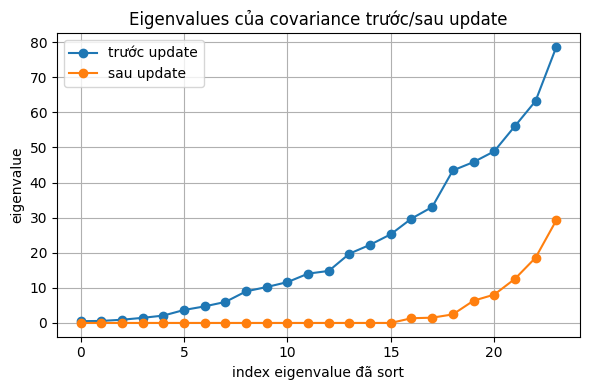

In [8]:
def covariance_diagnostics(P, name="P"):
    Psym = 0.5 * (P + P.T)
    eigs = np.linalg.eigvalsh(Psym)
    print(f"{name}: symmetry max|P-P.T| = {np.max(np.abs(P-P.T)):.3e}")
    print(f"{name}: min eig(sym(P))     = {eigs.min():.3e}")
    print(f"{name}: max eig(sym(P))     = {eigs.max():.3e}")
    print(f"{name}: trace              = {np.trace(P):.3e}")
    return eigs


def ieskf_cov_update_like_statehpp(P, H, meas_var, dofs2=24, dofobs=16):
    HTH = H.T @ H / meas_var
    Info = np.linalg.inv(P)
    Info[:dofobs, :dofobs] += HTH
    P_post = np.linalg.inv(Info)

    KH = np.zeros((dofs2, dofs2))
    KH[:, :dofobs] = P_post[:, :dofobs] @ HTH
    P_code = (np.eye(dofs2) - KH) @ P
    return P_post, P_code, KH

rng = np.random.default_rng(42)
A = rng.normal(size=(DoFS2, DoFS2))
P0 = A @ A.T + 0.5 * np.eye(DoFS2)
H_rand = rng.normal(size=(80, DoFObs))
meas_var = 0.05

P_post_direct, P_post_code, KH = ieskf_cov_update_like_statehpp(P0, H_rand, meas_var)

print("So sánh P_post trực tiếp với (I-KH)P:")
print("max absolute difference:", np.max(np.abs(P_post_direct - P_post_code)))
print()
_ = covariance_diagnostics(P0, "P trước update")
print()
_ = covariance_diagnostics(P_post_code, "P sau update kiểu code")

plt.figure(figsize=(6, 4))
plt.plot(np.linalg.eigvalsh(0.5 * (P0 + P0.T)), marker="o", label="trước update")
plt.plot(np.linalg.eigvalsh(0.5 * (P_post_code + P_post_code.T)), marker="o", label="sau update")
plt.title("Eigenvalues của covariance trước/sau update")
plt.xlabel("index eigenvalue đã sort")
plt.ylabel("eigenvalue")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## 7. Checklist debug thực tế cho `State::update()`

Khi chạy dataset thật, hãy log tối thiểu các đại lượng sau ở từng LiDAR frame và từng IESEKF iteration:

| Đại lượng | Kỳ vọng | Nếu bất thường thì nghi gì? |
|---|---|---|
| `valid_planes.size()` | đủ lớn và không về 0 liên tục | map rỗng, k-NN threshold quá chặt, deskew sai, extrinsic sai |
| `sqrt(z.squaredNorm()/z.size())` | giảm sau iteration | sai dấu `z`, Jacobian sai, plane association kém |
| `dx.lpNorm<Infinity>()` | giảm dần, cuối nhỏ hơn tolerance | noise/tolerance không hợp lý, H kém rank, outlier nhiều |
| `rank(H)` hoặc singular values | không quá suy biến | corridor/plane-only degeneracy, LiDAR ít feature |
| `minEig(sym(P))` | không âm đáng kể | projection/covariance update lỗi số, P không SPD |
| `norm(g)` | gần hằng số gravity | update S2 sai, dùng 3D gravity tự do |
| `P.trace()` | thường giảm sau update, tăng sau predict | noise Q/R sai scale hoặc update bị bỏ qua |

Mẫu log C++ gợi ý:

```cpp
const double rms_z = std::sqrt(z.squaredNorm() / std::max<int>(1, z.rows()));
const double dx_inf = dx.lpNorm<Eigen::Infinity>();
Eigen::SelfAdjointEigenSolver<Mat<DoFS2>> es(0.5 * (P + P.transpose()));
const double min_eig = es.eigenvalues().minCoeff();
std::cout << "iter=" << i
          << " planes=" << H.rows()
          << " rms_z=" << rms_z
          << " dx_inf=" << dx_inf
          << " minEigP=" << min_eig
          << std::endl;
```

Với debug nhanh, nên in thêm:

```cpp
std::cout << "H row norm mean = "
          << H.rowwise().norm().mean() << std::endl;
std::cout << "gravity norm = " << g().norm() << std::endl;
```


## 8. Test trực tiếp `h_model`: dấu residual và finite difference trong C++

Trong Python ta đã kiểm tra các công thức rút gọn. Khi nghi ngờ implementation thật, hãy test trực tiếp trên C++ theo quy trình này:

1. Chọn một `State s`, một điểm `p`, một plane `m.n`.
2. Tính residual gốc:

\[
r_0 = \operatorname{dist2plane}(m.n, s( p )).
\]

3. Lấy một hướng perturb \(e_i\), tạo `s_plus = s.plus(eps * e_i)` và `s_minus = s.plus(-eps * e_i)`.
4. Tính:

\[
J_{FD,i}=\frac{r(s_+)-r(s_-)}{2\epsilon}.
\]

5. So với hàng `H(i,:)` mà `h_model` trả về.

Cẩn thận với gravity:

- 22 chiều đầu dùng `X.plus(tau)` như bình thường.
- 2 chiều cuối dùng `S2::oplus(g(), delta.tail<2>())`.
- Không perturb gravity bằng cộng vector 3D nếu đang kiểm tra covariance 24D.

Pseudo-code:

```cpp
State perturb(State s, const Eigen::Matrix<double, DoFS2, 1>& dx) {
  State out = s;
  State::Tangent tau = State::Tangent::Zero();
  tau.coeffs().head(DoF-3) = dx.head(DoF-3);
  out.X = out.X.plus(tau);
  out.g(S2::oplus(out.g(), dx.tail<2>()));
  return out;
}
```

Nếu FD đúng nhưng filter vẫn không hội tụ, lỗi thường không còn nằm ở Jacobian đơn lẻ mà nằm ở:

- data association / plane fitting;
- threshold quá chặt/quá lỏng;
- `lidar_noise` sai scale;
- map chưa đủ điểm;
- deskew/time offset sai;
- degeneracy thật của môi trường.


## 9. Một “debug script” tối thiểu nên có trong repo

Bạn có thể biến notebook này thành unit test nhỏ cho repo:

- Test 1: `df_dx` bằng finite difference.
- Test 2: `df_dw` bằng finite difference.
- Test 3: point-to-plane Jacobian bằng finite difference.
- Test 4: covariance sau update phải symmetric-positive-semidefinite trong tolerance.
- Test 5: residual RMS của một synthetic plane phải giảm khi dùng `z=-r`, và tăng nếu cố tình đảo dấu.

Ngưỡng thực dụng:

| Test | Tolerance gợi ý |
|---|---:|
| Jacobian SO(3)/SE(3) với `double` | \(10^{-6}\) đến \(10^{-7}\) |
| Covariance symmetry | \(<10^{-9}\) nếu dữ liệu sạch |
| Min eigenvalue của `sym(P)` | \(>-10^{-10}\) |
| Residual RMS sau 2–3 iteration synthetic plane | giảm ít nhất 10–100 lần |

Nếu một Jacobian fail ở \(10^{-6}\) nhưng pass ở \(10^{-4}\), thường là công thức đúng nhưng hàm quá phi tuyến tại điểm test hoặc epsilon chưa phù hợp. Nếu fail với mọi epsilon, thường là sai dấu, sai frame, hoặc sai quy ước left/right perturbation.


## 10. Tóm tắt cách đọc kết quả

- `df_dx` đúng nếu block rotation cho velocity là:

\[
-[R^\top g]_\times.
\]

- `df_dw` đúng nếu noise gyro/accel có dấu âm, còn random walk bias có dấu dương.

- Residual LiDAR đúng nếu:

\[
H = \frac{\partial r}{\partial x},
\qquad
z=-r.
\]

- Với `SGal3::act`, cột time của Jacobian là velocity \(v\). Đây là hệ quả của right perturbation trên `SGal3`.

- Nếu residual tăng sau update, kiểm tra dấu `z`, frame của extrinsics, và liệu `H` đang là đạo hàm của `r` hay của `z`.

- Nếu filter không nổ nhưng drift, kiểm tra observability/rank của `H`: môi trường corridor, mặt phẳng đơn, hoặc ít feature thường không đủ ràng buộc mọi DoF.
